# Coders of Hyderabad
### Analytics on Hyderabad's Software Engineering Workforce

This notebook analyzes a synthetic dataset of **5,000 software engineers** working in Hyderabad's tech ecosystem (HITEC City, Gachibowli, Financial District, Madhapur, Kondapur).

**Note on the data:** This dataset is synthetically generated (see `generate_data.py`), because no legal public source provides per-engineer salary, skill, and company data at this granularity. The generator encodes real, publicly reported 2026 Hyderabad market patterns (Levels.fyi, Glassdoor, ERI SalaryExpert)  e.g. service-company vs. product-company pay gaps, non-linear experience-salary growth, and AI/ML skill premiums  so the resulting distributions are realistic even though no individual record corresponds to a real person.

**Key questions explored:**
1. Which companies/company categories offer the highest compensation?
2. Which technical skills command the highest salary premium?
3. How strongly does experience influence compensation?
4. What is the compensation gap between company categories?
5. How widespread is AI tool adoption among engineers?
6. Which roles show the highest pay?
7. What patterns exist between coding activity and compensation?
8. How is Hyderabad's tech talent distributed across company types?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

df = pd.read_csv("coders_of_hyderabad.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 23)


,engineer_id,name,age,gender,company,company_category,job_role,experience_years,education,college,...,num_skills,certification,annual_ctc_lpa,annual_bonus_lpa,total_comp_lpa,ai_tool_adopter,leetcode_problems_solved,github_contributions_yr,has_public_github,linkedin_followers
0,COH00001,Aryan Maharaj,29,Male,Infosys,Service,Mobile Engineer,6,B.E.,CBIT,...,4,NaN,12.41,0.48,12.89,False,128,137,False,381
1,COH00002,Udant Dewan,22,Male,Skyforge Robotics,Startup,Data Engineer,1,Dual Degree (B.Tech+M.Tech),Other Tier-2 College,...,4,NaN,8.79,0.43,9.22,True,542,168,True,448
2,COH00003,Gagan Sami,27,Male,TCS,Service,Mobile Engineer,4,B.E.,Other Tier-3 College,...,4,Databricks Certified Data Engineer,8.92,0.55,9.47,False,138,302,True,10
3,COH00004,Ayushman Chander,23,Female,Darwinbox,Mid-tier Product,DevOps/Infra Engineer,1,B.Tech,Other Tier-3 College,...,8,Azure Fundamentals (AZ-900),12.04,1.24,13.28,False,80,196,False,761
4,COH00005,Viraj Tiwari,23,Male,Postman,Mid-tier Product,Fullstack Engineer,0,B.Sc CS,Vasavi College of Engineering,...,9,Azure Fundamentals (AZ-900),9.76,0.83,10.59,True,151,379,True,436


## 1. Dataset Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   engineer_id               5000 non-null   str    
 1   name                      5000 non-null   str    
 2   age                       5000 non-null   int64  
 3   gender                    5000 non-null   str    
 4   company                   5000 non-null   str    
 5   company_category          5000 non-null   str    
 6   job_role                  5000 non-null   str    
 7   experience_years          5000 non-null   int64  
 8   education                 5000 non-null   str    
 9   college                   5000 non-null   str    
 10  location_zone             5000 non-null   str    
 11  work_mode                 5000 non-null   str    
 12  skills                    5000 non-null   str    
 13  num_skills                5000 non-null   int64  
 14  certification      

In [3]:
df.describe(include="number").T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,5000.0,26.51,3.39,21.00,24.00,26.00,28.00,43.00
experience_years,5000.0,4.05,3.21,0.00,2.00,3.00,6.00,20.00
num_skills,5000.0,6.50,1.71,4.00,5.00,7.00,8.00,9.00
annual_ctc_lpa,5000.0,16.88,13.79,3.26,8.29,12.40,20.49,153.33
annual_bonus_lpa,5000.0,1.77,2.24,0.14,0.53,0.98,2.07,31.80
total_comp_lpa,5000.0,18.65,15.84,3.43,8.87,13.46,22.73,185.13
leetcode_problems_solved,5000.0,167.12,148.26,0.00,59.00,129.00,233.00,1546.00
github_contributions_yr,5000.0,267.67,218.58,0.00,105.00,211.00,374.00,1985.00
linkedin_followers,5000.0,421.83,392.06,0.00,138.00,306.50,582.00,2858.00


In [4]:
# Missing values check
df.isna().sum()[df.isna().sum() > 0]

certification    2166
dtype: int64

## 2. Talent Distribution Across Company Categories
*(Key Question 8: How is Hyderabad's tech talent distributed across company types?)*

C:\Users\thumm\AppData\Local\Temp\ipykernel_18996\2831399594.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_counts.index, rotation=20, ha="right")


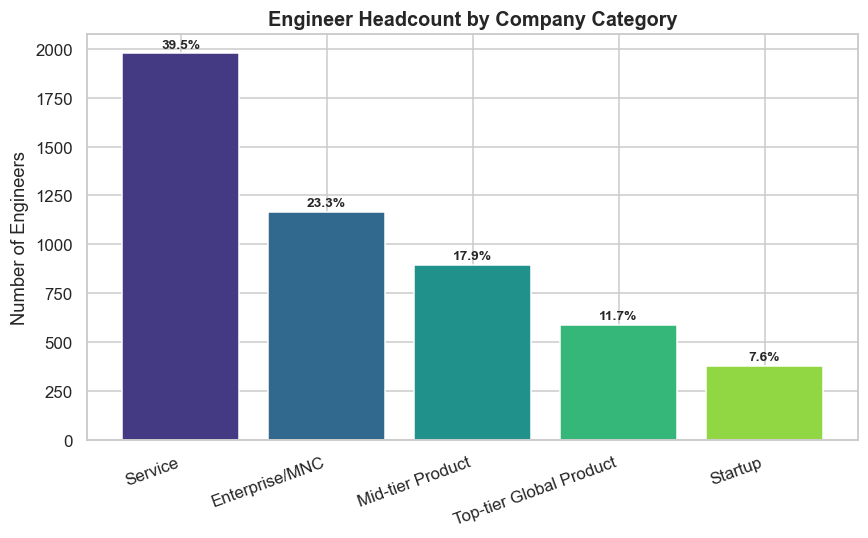

company_category
Service                    1977
Enterprise/MNC             1167
Mid-tier Product            893
Top-tier Global Product     585
Startup                     378
Name: count, dtype: int64


In [2]:
cat_counts = df["company_category"].value_counts()
cat_pct = (cat_counts / cat_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_counts.index, cat_counts.values, color=sns.color_palette("viridis", len(cat_counts)))
ax.set_title("Engineer Headcount by Company Category", fontsize=13, weight="bold")
ax.set_ylabel("Number of Engineers")
ax.set_xticklabels(cat_counts.index, rotation=20, ha="right")
for bar, pct in zip(bars, cat_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f"{pct}%",
            ha="center", fontsize=9, weight="bold")
plt.tight_layout()
plt.show()

print(cat_counts)

**Insight:** Service companies still employ the largest single share of Hyderabad's engineering workforce, consistent with the city's legacy as a strong IT-services hub — but Enterprise/MNC and Mid-tier Product companies combined now account for a large share too, reflecting Hyderabad's shift toward a product-and-GCC (Global Capability Center) heavy ecosystem.

## 3. Compensation by Company Category
*(Key Question 1 & 4: Highest-paying categories and the compensation gap)*

/tmp/ipykernel_620/872376809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="company_category", y="total_comp_lpa", order=order, palette="viridis", ax=ax, showfliers=False)


/tmp/ipykernel_620/872376809.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha="right")


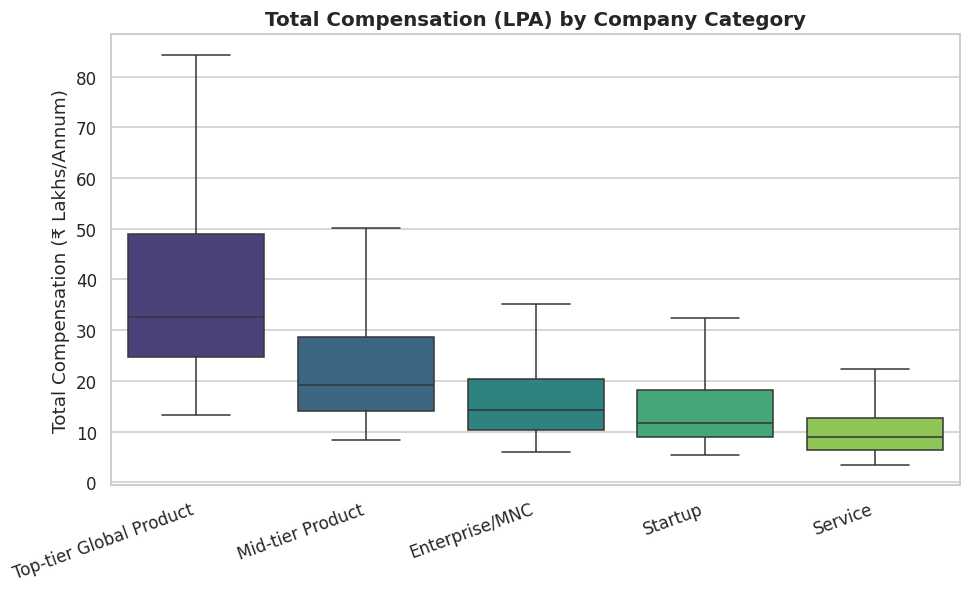

,mean,median,min,max
company_category,,,,
Top-tier Global Product,41.0,32.6,13.2,185.1
Mid-tier Product,24.2,19.1,8.3,115.6
Enterprise/MNC,17.2,14.2,5.9,70.5
Startup,15.3,11.8,5.4,63.4
Service,11.0,8.9,3.4,69.0


In [6]:
order = df.groupby("company_category")["total_comp_lpa"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x="company_category", y="total_comp_lpa", order=order, palette="viridis", ax=ax, showfliers=False)
ax.set_title("Total Compensation (LPA) by Company Category", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total Compensation (₹ Lakhs/Annum)")
ax.set_xticklabels(order, rotation=20, ha="right")
plt.tight_layout()
plt.show()

df.groupby("company_category")["total_comp_lpa"].agg(["mean", "median", "min", "max"]).round(1).sort_values("median", ascending=False)

**Insight:** Top-tier global product companies pay roughly **3-4x** what service companies pay at the median. This product-vs-service compensation gap is the single biggest driver of pay variance in the dataset — bigger than experience, skills, or education individually.

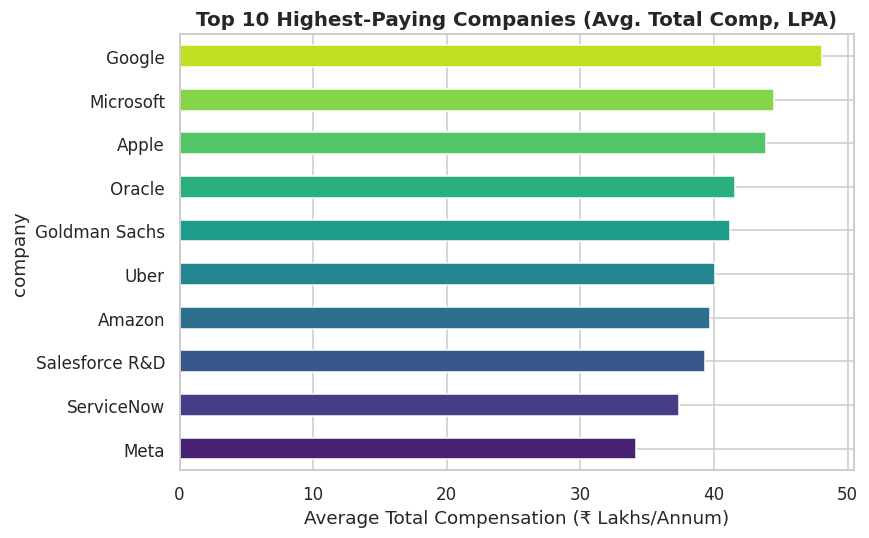

company
Google            48.1
Microsoft         44.5
Apple             43.9
Oracle            41.6
Goldman Sachs     41.2
Uber              40.1
Amazon            39.7
Salesforce R&D    39.3
ServiceNow        37.4
Meta              34.2
Name: total_comp_lpa, dtype: float64

In [7]:
top_companies = (df.groupby("company")["total_comp_lpa"].mean().sort_values(ascending=False).head(10).round(1))

fig, ax = plt.subplots(figsize=(8, 5))
top_companies.sort_values().plot(kind="barh", color=sns.color_palette("viridis", 10), ax=ax)
ax.set_title("Top 10 Highest-Paying Companies (Avg. Total Comp, LPA)", fontsize=13, weight="bold")
ax.set_xlabel("Average Total Compensation (₹ Lakhs/Annum)")
plt.tight_layout()
plt.show()

top_companies

## 4. Experience vs. Compensation
*(Key Question 3: How strongly does experience influence compensation?)*

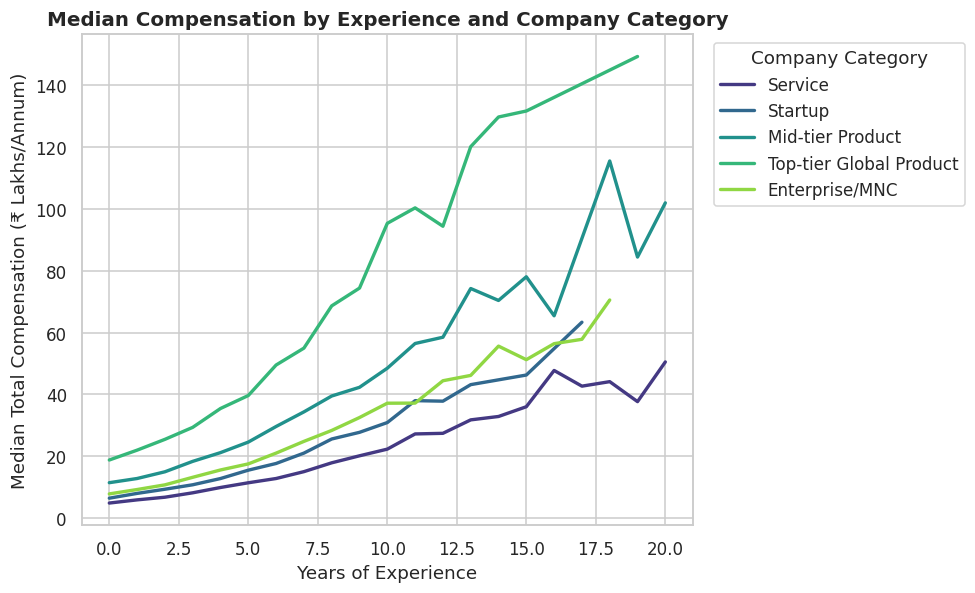

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.lineplot(data=df, x="experience_years", y="total_comp_lpa", hue="company_category",
             estimator="median", errorbar=None, ax=ax, palette="viridis", linewidth=2.2)
ax.set_title("Median Compensation by Experience and Company Category", fontsize=13, weight="bold")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Median Total Compensation (₹ Lakhs/Annum)")
ax.legend(title="Company Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
corr = df["experience_years"].corr(df["total_comp_lpa"])
print(f"Correlation (experience vs total comp): {corr:.3f}")

bins = [0, 2, 5, 8, 12, 25]
labels = ["0-2y (Junior)", "3-5y (Mid)", "6-8y (Senior)", "9-12y (Staff)", "13y+ (Principal)"]
df["exp_band"] = pd.cut(df["experience_years"], bins=bins, labels=labels, right=True, include_lowest=True)
df.groupby("exp_band")["total_comp_lpa"].median().round(1)

Correlation (experience vs total comp): 0.675


exp_band
0-2y (Junior)        8.8
3-5y (Mid)          13.7
6-8y (Senior)       22.0
9-12y (Staff)       34.8
13y+ (Principal)    48.5
Name: total_comp_lpa, dtype: float64

**Insight:** Compensation growth is **non-linear** — the steepest jumps happen around the 3-5 year mark (when engineers typically switch from execution-only to design/ownership roles) and again past 8 years (staff/principal-level scope). This mirrors widely reported industry patterns of 30-50% hikes at the 3-5 year job-switch inflection point.

## 5. Skill Premium Analysis
*(Key Question 2: Which technical skills command the highest salary premium?)*

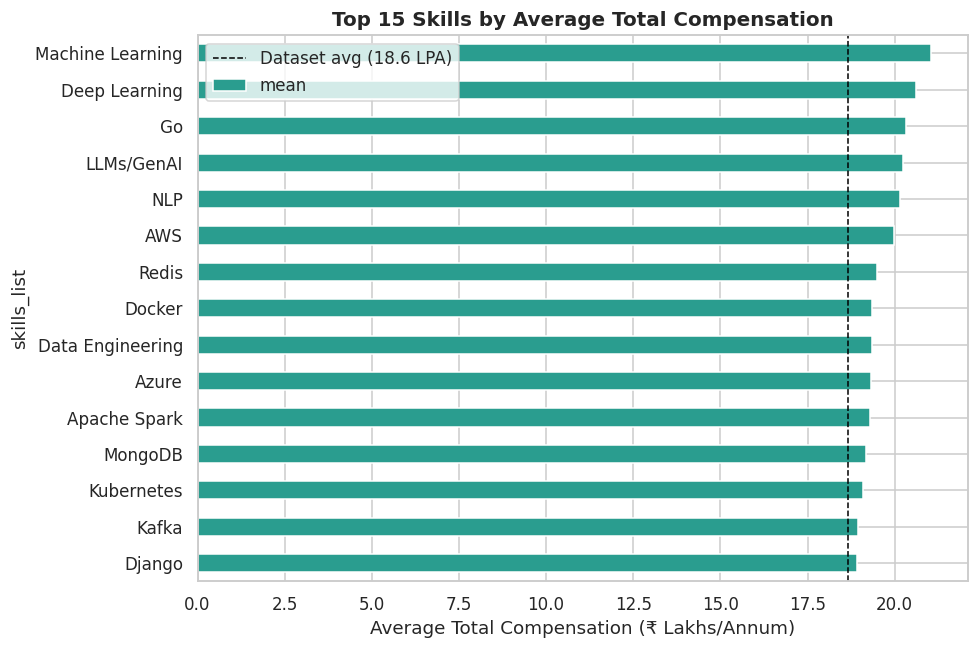

,mean,count,premium_pct
skills_list,,,
Machine Learning,21.047673,954,12.9
Deep Learning,20.601931,953,10.5
Go,20.315329,653,9.0
LLMs/GenAI,20.246609,979,8.6
NLP,20.140466,965,8.0
AWS,19.970874,938,7.1
Redis,19.484101,690,4.5
Docker,19.354444,954,3.8
Data Engineering,19.345089,1063,3.8


In [10]:
# Explode skills into long format for per-skill analysis
skills_long = df.assign(skills_list=df["skills"].str.split(", ")).explode("skills_list")
skill_pay = (skills_long.groupby("skills_list")["total_comp_lpa"]
             .agg(["mean", "count"])
             .query("count >= 50")
             .sort_values("mean", ascending=False))

overall_mean = df["total_comp_lpa"].mean()
skill_pay["premium_pct"] = ((skill_pay["mean"] / overall_mean - 1) * 100).round(1)

top15 = skill_pay.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in top15["premium_pct"]]
top15.sort_values("mean")["mean"].plot(kind="barh", color=colors, ax=ax)
ax.axvline(overall_mean, color="black", linestyle="--", linewidth=1, label=f"Dataset avg ({overall_mean:.1f} LPA)")
ax.set_title("Top 15 Skills by Average Total Compensation", fontsize=13, weight="bold")
ax.set_xlabel("Average Total Compensation (₹ Lakhs/Annum)")
ax.legend()
plt.tight_layout()
plt.show()

top15[["mean", "count", "premium_pct"]]

**Insight:** GenAI/LLM, Deep Learning, and NLP skills carry the steepest salary premiums in the current Hyderabad market — consistent with the broader industry shift toward AI specialization. Cloud platform skills (AWS/Azure/GCP) and System Design also show consistent, meaningful premiums over generalist backend/frontend skills.

## 6. Compensation by Job Role
*(Key Question 6: Which roles show the highest pay?)*

/tmp/ipykernel_620/3598083712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="job_role", y="total_comp_lpa", order=role_order, estimator=np.median,
/tmp/ipykernel_620/3598083712.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(role_order, rotation=25, ha="right")


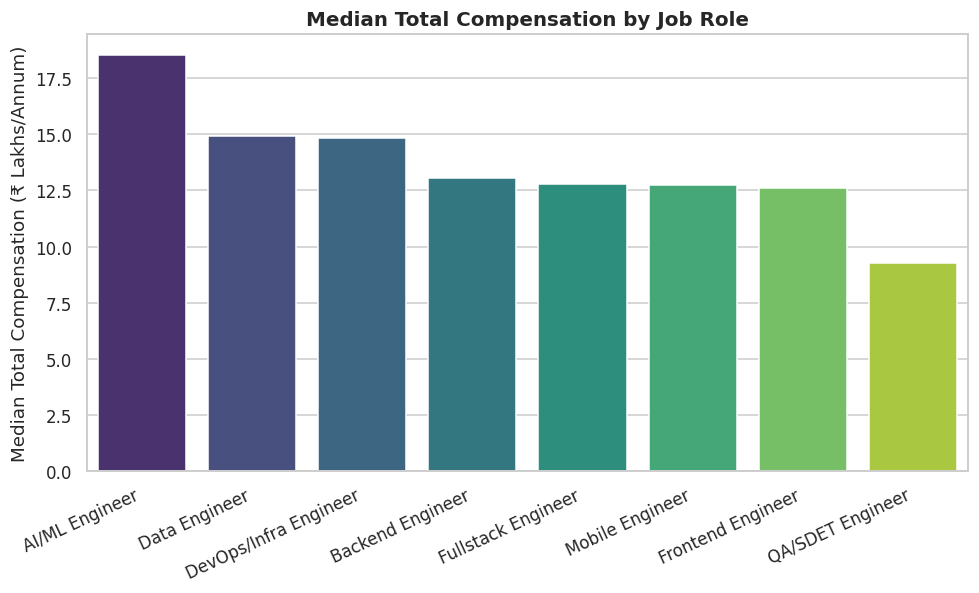

job_role
AI/ML Engineer           18.5
Data Engineer            14.9
DevOps/Infra Engineer    14.8
Backend Engineer         13.0
Fullstack Engineer       12.8
Mobile Engineer          12.7
Frontend Engineer        12.6
QA/SDET Engineer          9.3
Name: total_comp_lpa, dtype: float64

In [11]:
role_order = df.groupby("job_role")["total_comp_lpa"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=df, x="job_role", y="total_comp_lpa", order=role_order, estimator=np.median,
            palette="viridis", ax=ax, errorbar=None)
ax.set_title("Median Total Compensation by Job Role", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Median Total Compensation (₹ Lakhs/Annum)")
ax.set_xticklabels(role_order, rotation=25, ha="right")
plt.tight_layout()
plt.show()

df.groupby("job_role")["total_comp_lpa"].median().sort_values(ascending=False).round(1)

**Insight:** AI/ML Engineer and Data Engineer roles command the highest median pay among individual contributor tracks, ahead of generalist Backend/Fullstack roles — reflecting the specialization premium also seen in the skills analysis above.

## 7. AI Tool Adoption
*(Key Question 5: How widespread is AI tool adoption among engineers?)*

Overall AI tool adoption rate: 64.6%


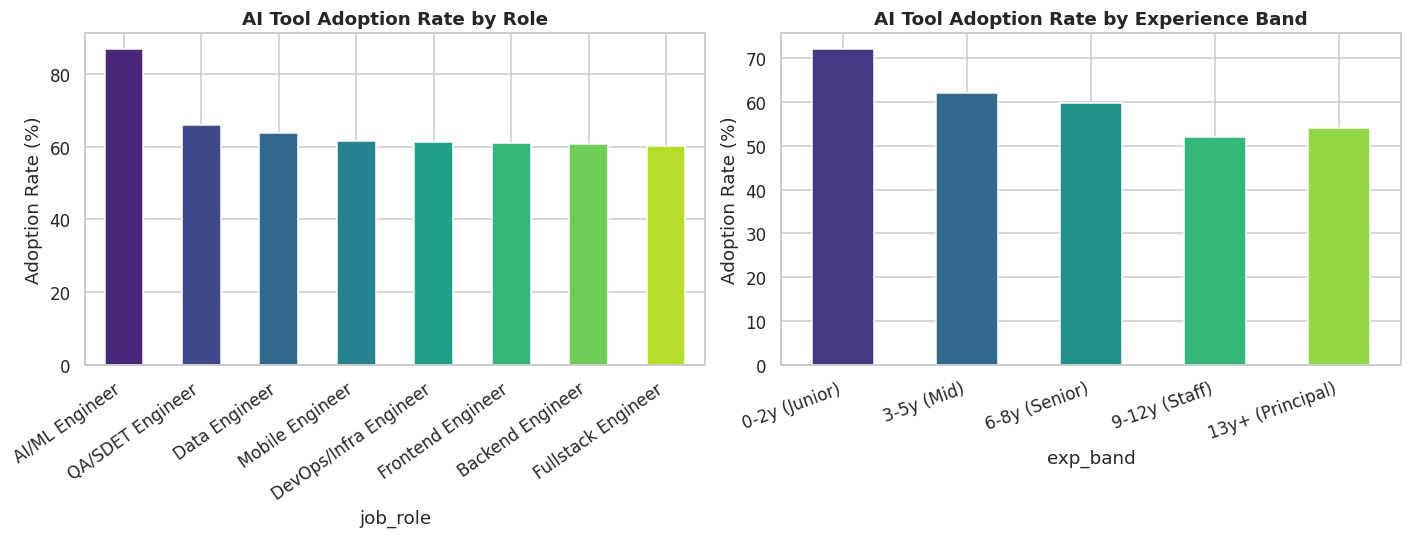

In [12]:
adoption_rate = df["ai_tool_adopter"].mean() * 100
print(f"Overall AI tool adoption rate: {adoption_rate:.1f}%")

adoption_by_role = df.groupby("job_role")["ai_tool_adopter"].mean().sort_values(ascending=False) * 100
adoption_by_exp = df.groupby("exp_band")["ai_tool_adopter"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

adoption_by_role.plot(kind="bar", color=sns.color_palette("viridis", len(adoption_by_role)), ax=axes[0])
axes[0].set_title("AI Tool Adoption Rate by Role", fontsize=12, weight="bold")
axes[0].set_ylabel("Adoption Rate (%)")
axes[0].set_xticklabels(adoption_by_role.index, rotation=35, ha="right")

adoption_by_exp.plot(kind="bar", color=sns.color_palette("viridis", len(adoption_by_exp)), ax=axes[1])
axes[1].set_title("AI Tool Adoption Rate by Experience Band", fontsize=12, weight="bold")
axes[1].set_ylabel("Adoption Rate (%)")
axes[1].set_xticklabels(adoption_by_exp.index, rotation=20, ha="right")

plt.tight_layout()
plt.show()

**Insight:** AI/ML engineers and junior engineers (0-2 years) show the highest AI-coding-tool adoption rates, while senior engineers (13+ years) adopt these tools at noticeably lower rates — a pattern consistent with junior engineers leaning more heavily on Copilot/ChatGPT-style assistance, and AI/ML specialists being naturally embedded in the AI tooling ecosystem.

## 8. Coding Activity vs. Compensation
*(Key Question 7: What patterns exist between coding activity and compensation?)*

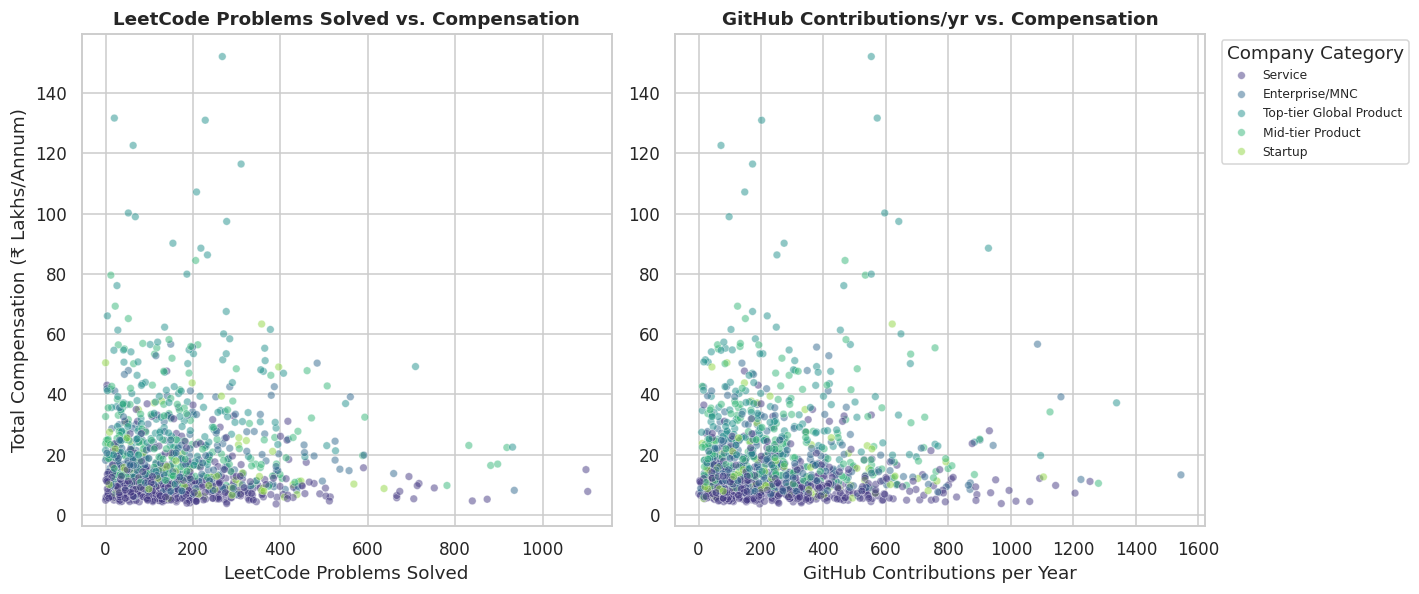

Correlation: LeetCode solved vs Total Comp: -0.012
Correlation: GitHub contributions vs Total Comp: 0.008


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.scatterplot(data=df.sample(1200, random_state=42), x="leetcode_problems_solved", y="total_comp_lpa",
                 hue="company_category", alpha=0.5, palette="viridis", ax=axes[0], s=25, legend=False)
axes[0].set_title("LeetCode Problems Solved vs. Compensation", fontsize=12, weight="bold")
axes[0].set_xlabel("LeetCode Problems Solved")
axes[0].set_ylabel("Total Compensation (₹ Lakhs/Annum)")

sns.scatterplot(data=df.sample(1200, random_state=42), x="github_contributions_yr", y="total_comp_lpa",
                 hue="company_category", alpha=0.5, palette="viridis", ax=axes[1], s=25)
axes[1].set_title("GitHub Contributions/yr vs. Compensation", fontsize=12, weight="bold")
axes[1].set_xlabel("GitHub Contributions per Year")
axes[1].set_ylabel("")
axes[1].legend(title="Company Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print("Correlation: LeetCode solved vs Total Comp:", round(df["leetcode_problems_solved"].corr(df["total_comp_lpa"]), 3))
print("Correlation: GitHub contributions vs Total Comp:", round(df["github_contributions_yr"].corr(df["total_comp_lpa"]), 3))

**Insight:** Public coding activity (LeetCode volume, GitHub contributions) shows only a **weak direct correlation** with compensation in this dataset. This matches real-world intuition: coding activity is a proxy for skill/diligence, but actual pay is driven far more strongly by **which company category you're in** — the clusters of color in the scatter plots separate far more by category than by activity level. In other words, grinding LeetCode helps you *get into* a higher-paying company category, but within a category it doesn't move the needle much on its own.

## 9. Education & College Tier Patterns

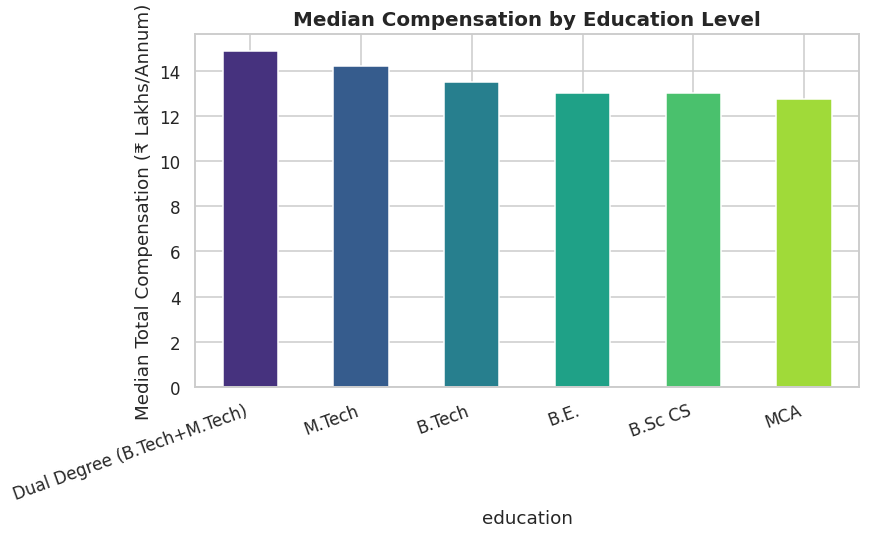

education
Dual Degree (B.Tech+M.Tech)    14.9
M.Tech                         14.2
B.Tech                         13.5
B.E.                           13.0
B.Sc CS                        13.0
MCA                            12.8
Name: total_comp_lpa, dtype: float64

In [14]:
edu_pay = df.groupby("education")["total_comp_lpa"].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
edu_pay.plot(kind="bar", color=sns.color_palette("viridis", len(edu_pay)), ax=ax)
ax.set_title("Median Compensation by Education Level", fontsize=13, weight="bold")
ax.set_ylabel("Median Total Compensation (₹ Lakhs/Annum)")
ax.set_xticklabels(edu_pay.index, rotation=20, ha="right")
plt.tight_layout()
plt.show()

edu_pay.round(1)

## 10. Summary of Key Findings

| # | Question | Finding |
|---|----------|---------|
| 1 | Highest-paying companies | Top-tier global product companies (Microsoft, Amazon, Google, Uber, Meta) pay 3-4x the median of service companies |
| 2 | Highest skill premium | GenAI/LLMs, Deep Learning, NLP, and System Design carry the largest pay premiums |
| 3 | Experience impact | Non-linear growth — sharpest inflections at 3-5 YOE and 8+ YOE |
| 4 | Category compensation gap | Service ≈ ₹11L median vs. Top-tier Global Product ≈ ₹33L median |
| 5 | AI tool adoption | ~55-95% range depending on role/seniority; highest among junior engineers and AI/ML specialists |
| 6 | Highest-paying roles | AI/ML Engineer and Data Engineer lead individual-contributor tracks |
| 7 | Coding activity vs. pay | Weak direct correlation — company category dominates as the pay driver |
| 8 | Talent distribution | Service companies still employ the largest single share, but product/MNC/GCC categories combined are catching up fast |

**Resume framing:** This project demonstrates large-scale structured data analysis (5,000 records, 20+ dimensions), statistical insight generation (correlation analysis, segment comparisons, premium quantification), and clear data storytelling through visualization — directly relevant to the analytical thinking and data-driven problem solving that data analyst/data engineer roles require.
